# Dataset Conciertos

Este código llama a la API de Setlist.fm, recorre de forma automática todas las páginas de resultados de conciertos en Chicago desde el año 2012 hasta el 2026, y guarda todo en un archivo CSV limpio.

Vamos a filtrar los recintos para quedarnos únicamente con los que causan caos vehicular.

Limitaciones:

- Setlist.fm depende de que usuarios hayan subido el setlist, puede que falten conciertos reales si nadie lo registró ahí. 

- Solo capturamos conciertos musicales.

## 0. Importación de paquetes

In [ ]:
import math
import time
import requests
import pandas as pd
from datetime import datetime
from tqdm import tqdm

from EDA_general import *
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

## 1. Descarga de datos

In [ ]:
HEADERS = {
    "x-api-key": API_concerts,
    "Accept": "application/json"
}

# Recintos que generan impacto en el tráfico
VENUES = {
    "Soldier Field": "4bd637ce",
    "Wrigley Field": "53d6cf29",
    "United Center": "63d0f2d3",
    "Charter One Pavilion": "53d6cb95", # 1. 2005-2013
    "FirstMerit Bank Pavilion at Northerly Island": "1bd499d4", # 2. 2013-2017
    "Huntington Bank Pavilion at Northerly Island": "23d54827", # 3. desde 2017
    "Credit Union 1 Arena": "bd3dd06", # 1. desde 2018
    "UIC Pavilion": "7bd62658", # 2. hasta 2018
}

all_concerts = []

for venue_name, venue_id in VENUES.items():

    print(f"\nProcesando {venue_name}")

    url = f"https://api.setlist.fm/rest/1.0/venue/{venue_id}/setlists"

    page = 1
    total_pages = None

    while True:

        response = requests.get(
            url,
            headers=HEADERS,
            params={"p": page}
        )

        if response.status_code != 200:
            print(f"Error {response.status_code} en {venue_name}")
            break

        data = response.json()

        if total_pages is None:

            total = data.get("total", 0)
            items = data.get("itemsPerPage", 20)

            total_pages = max(1, math.ceil(total / items))

            pbar = tqdm(
                total=total_pages,
                desc=venue_name,
                leave=False
            )

        setlists = data.get("setlist", [])

        if not setlists:
            break

        for s in setlists:

            try:

                date = datetime.strptime(
                    s["eventDate"],
                    "%d-%m-%Y"
                )

                if 2012 <= date.year <= 2026:

                    all_concerts.append({

                        "date": date.strftime("%Y-%m-%d"),
                        "venue_name": s["venue"]["name"],
                        "venue_id": venue_id

                    })

            except Exception:
                continue

        pbar.update(1)

        if page >= total_pages:
            break

        page += 1
        time.sleep(1)

    if total_pages is not None:
        pbar.close()

df_conciertos = pd.DataFrame(all_concerts)

df_conciertos = df_conciertos.drop_duplicates()

df_conciertos = df_conciertos.sort_values("date")

df_conciertos.reset_index(drop=True, inplace=True)

print(f"\nTotal conciertos: {len(df_conciertos)}")


Procesando Soldier Field



Procesando Wrigley Field



Procesando United Center



Procesando Charter One Pavilion



Procesando FirstMerit Bank Pavilion



Procesando Huntington Bank Pavilion at Northerly Island



Procesando Credit Union 1 Arena



Procesando UIC Pavilion



Total conciertos: 1185


Añadimos las coordenadas (sacados de openstreetmap) de cada recinto para asi poder juntarlos con los demás csvs.

In [ ]:
# Coordenadas de los recintos
coordenadas = {

    "Soldier Field": {
        "latitude": 41.862474,
        "longitude": -87.618070
    },

    "Wrigley Field": {
        "latitude": 41.948167,
        "longitude": -87.655557
    },

    "United Center": {
        "latitude": 41.880677,
        "longitude": -87.674149
    },

    "Charter One Pavilion": {
        "latitude": 41.862646,
        "longitude": -87.608556
    },

    "FirstMerit Bank Pavilion at Northerly Island": {
        "latitude": 41.862646,
        "longitude": -87.608556
    },

    "Huntington Bank Pavilion at Northerly Island": {
        "latitude": 41.862646,
        "longitude": -87.608556
    },

    "Credit Union 1 Arena": {
        "latitude": 41.874772,
        "longitude": -87.656152
    },

    "UIC Pavilion": {
        "latitude": 41.874772,
        "longitude": -87.656152
        }
}

# Añadimos las coordenadas
df_conciertos["latitude"] = df_conciertos["venue_name"].map(
    lambda x: coordenadas[x]["latitude"]
)

df_conciertos["longitude"] = df_conciertos["venue_name"].map(
    lambda x: coordenadas[x]["longitude"]
)

# quitamos venue_id
df_conciertos = df_conciertos.drop(columns=["venue_id"])

df_conciertos.to_csv("data_clean/concerts.csv", index=False)

# imprimimos las primeras 5 filas
print(df_conciertos.head())

         date     venue_name   latitude  longitude
0  2012-01-27   UIC Pavilion  41.874772 -87.656152
1  2012-02-24  United Center  41.880677 -87.674149
2  2012-03-19  United Center  41.880677 -87.674149
3  2012-06-08  Wrigley Field  41.948167 -87.655557
4  2012-06-09  Wrigley Field  41.948167 -87.655557


## 2. EDA

In [8]:
# 1. CARGA Y VISION GENERAL
resumen_general(df_conciertos)

Dimensiones: 1,185 filas x 4 columnas

Tipos de dato por columna:
date              str
venue_name        str
latitude      float64
longitude     float64
dtype: object

Primeras filas:
         date     venue_name   latitude  longitude
0  2012-01-27   UIC Pavilion  41.874772 -87.656152
1  2012-02-24  United Center  41.880677 -87.674149
2  2012-03-19  United Center  41.880677 -87.674149
3  2012-06-08  Wrigley Field  41.948167 -87.655557
4  2012-06-09  Wrigley Field  41.948167 -87.655557


In [9]:
# 2. CALIDAD DE DATOS
calidad_datos(df_conciertos)
dup_count = df_conciertos.duplicated().sum()
print(f"Filas duplicadas: {dup_count:,} de {len(df_conciertos):,} "
      f"({dup_count / len(df_conciertos) * 100:.1f}%)")

Valores nulos por columna:
Empty DataFrame
Columns: [nulos, % nulos]
Index: []
Filas duplicadas: 0 de 1,185 (0.0%)


Fechas que no se pudieron parsear: 0
Rango de fechas: 2012-01-27 00:00:00 -> 2026-08-06 00:00:00


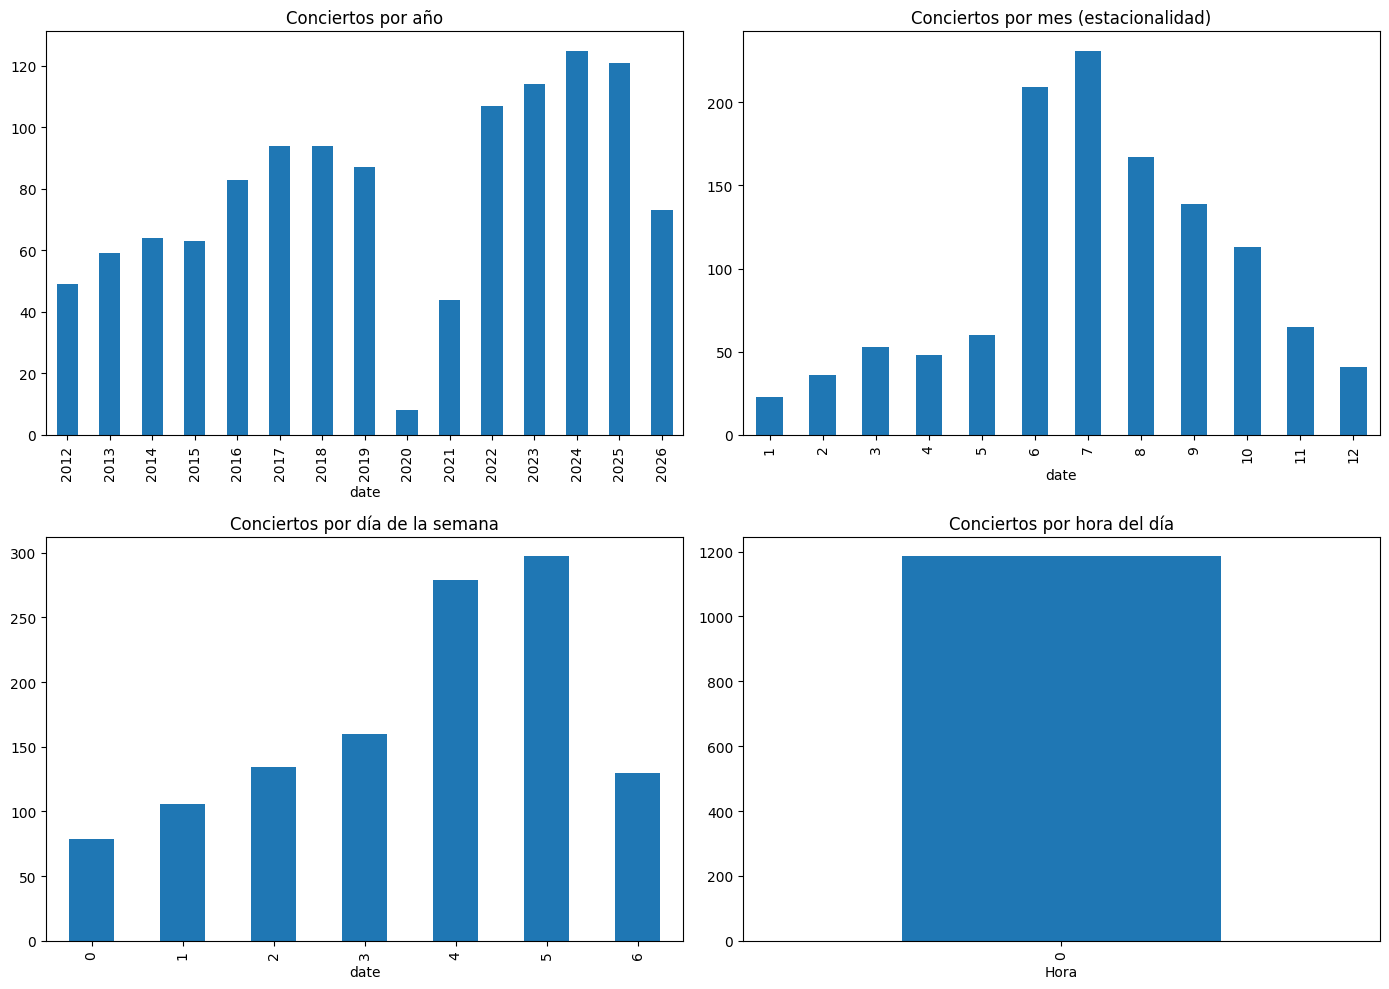

0      2012-01-27
1      2012-02-24
2      2012-03-19
3      2012-06-08
4      2012-06-09
          ...    
1180   2026-07-25
1181   2026-07-26
1182   2026-08-03
1183   2026-08-05
1184   2026-08-06
Name: date, Length: 1185, dtype: datetime64[us]

In [10]:
# 3. ANALISIS TEMPORAL
analisis_temporal(df_conciertos, date_col="date", date_format="%Y-%m-%d", evento="Conciertos")

In [11]:
# 4. ANÁLISIS POR RECINTO
analisis_calles(df_conciertos, street_col="venue_name")

Top 15 'venue_name' con más registros:
venue_name
United Center                                   601
Huntington Bank Pavilion at Northerly Island    224
Soldier Field                                   103
Wrigley Field                                    99
FirstMerit Bank Pavilion at Northerly Island     78
UIC Pavilion                                     39
Credit Union 1 Arena                             27
Charter One Pavilion                             14
Name: count, dtype: int64


In [ ]:
# 5. ANALISIS GEOGRÁFICO
analisis_geografico(df_conciertos, lat_col='latitude', lon_col='longitude')